In [1]:
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales_data_updated.csv")
df["order_date"] = pd.to_datetime(df["order_date"])
df.head()

Mounted at /content/drive
/content/drive/MyDrive


,order_date,time,aging,customer_id,gender,device_type,customer_login_type,product_category,product,sales,quantity,discount,profit,shipping_cost,order_priority,payment_method
0,2018-01-01,10:11:40,5.0,29317,Male,Web,Member,Auto & Accessories,Car Media Players,140.0,4.0,0.3,43.2,4.3,Medium,e_wallet
1,2018-01-01,22:30:44,7.0,42270,Male,Web,Member,Auto & Accessories,Car Pillow & Neck Rest,231.0,5.0,0.1,139.5,13.9,High,money_order
2,2018-01-01,21:55:31,10.0,14563,Male,Web,Member,Auto & Accessories,Car Speakers,211.0,5.0,0.1,120.5,12.0,High,credit_card
3,2018-01-01,13:57:15,9.0,58601,Male,Web,Member,Auto & Accessories,Tyre,250.0,4.0,0.2,150.0,15.0,Critical,credit_card
4,2018-01-01,15:17:41,2.0,48342,Male,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.1,165.0,16.5,High,credit_card


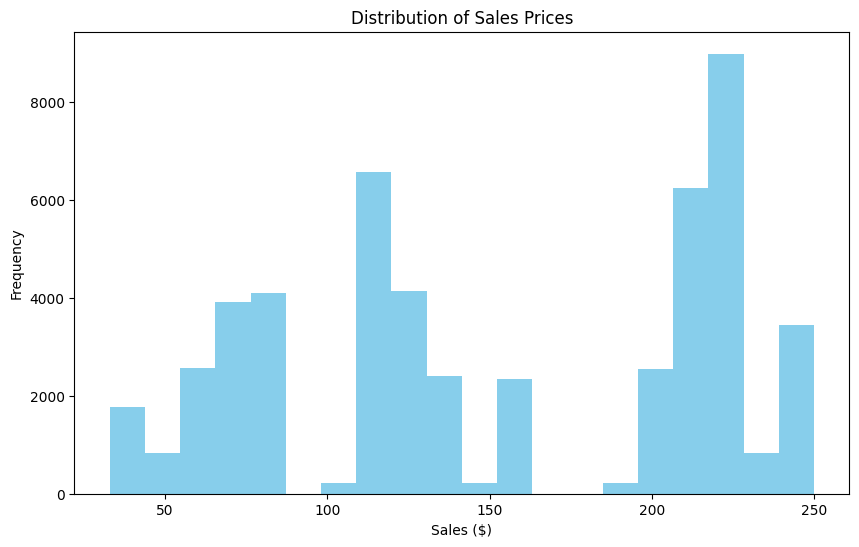

In [2]:
plt.figure(figsize=(10, 6))
plt.hist(df["sales"], bins=20, color="skyblue")
plt.title("Distribution of Sales Prices")
plt.xlabel("Sales ($)")
plt.ylabel("Frequency")
plt.show()

## Distribuição de Vendas
Os preços mais comuns estão nas faixas de $110-120 e $220-230.
A distribuição é bimodal — há dois picos claros, sugerindo dois grupos de produtos com preços distintos.

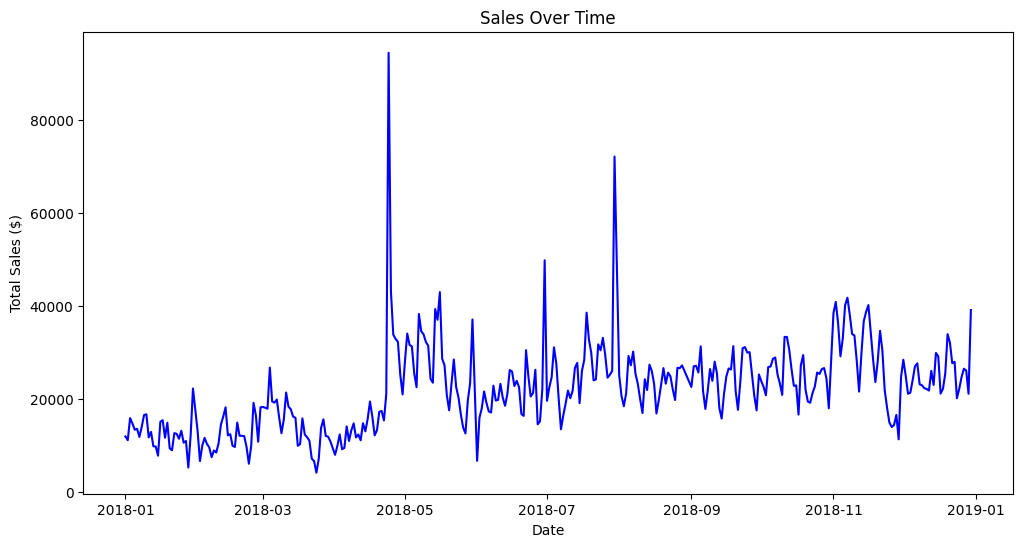

In [3]:
sales_over_time = df.groupby("order_date")["sales"].sum()

plt.figure(figsize=(12, 6))
plt.plot(sales_over_time.index, sales_over_time.values, color="blue")
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales ($)")
plt.show()

## Vendas ao Longo do Tempo
As vendas cresceram significativamente a partir de março/2018.
Há picos pontuais em maio e julho/2018. A tendência geral é de crescimento com muita variação diária.

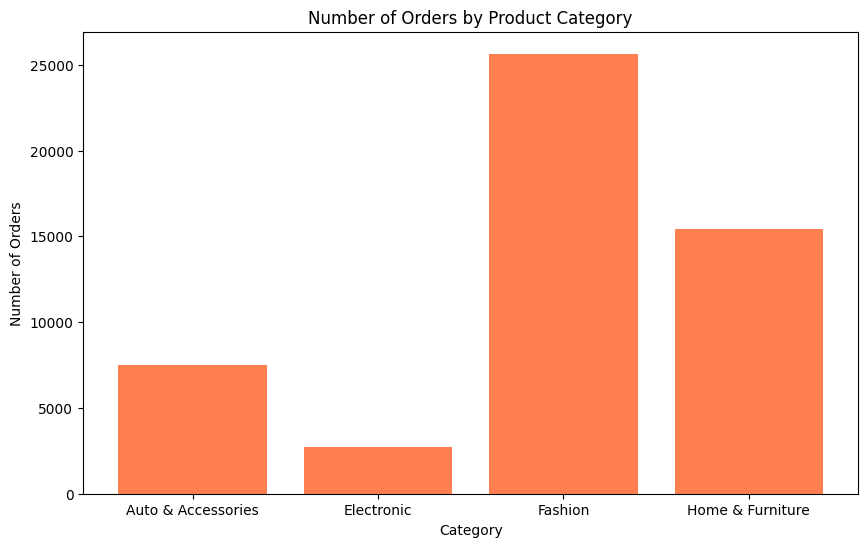

In [4]:
category_orders = df.groupby("product_category")["sales"].count()

plt.figure(figsize=(10, 6))
plt.bar(category_orders.index, category_orders.values, color="coral")
plt.title("Number of Orders by Product Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.show()

## Pedidos por Categoria
- **Mais popular:** Fashion com ~25.000 pedidos
- **Menos popular:** Electronic com ~2.700 pedidos
- Home & Furniture e Auto & Accessories ficam no meio

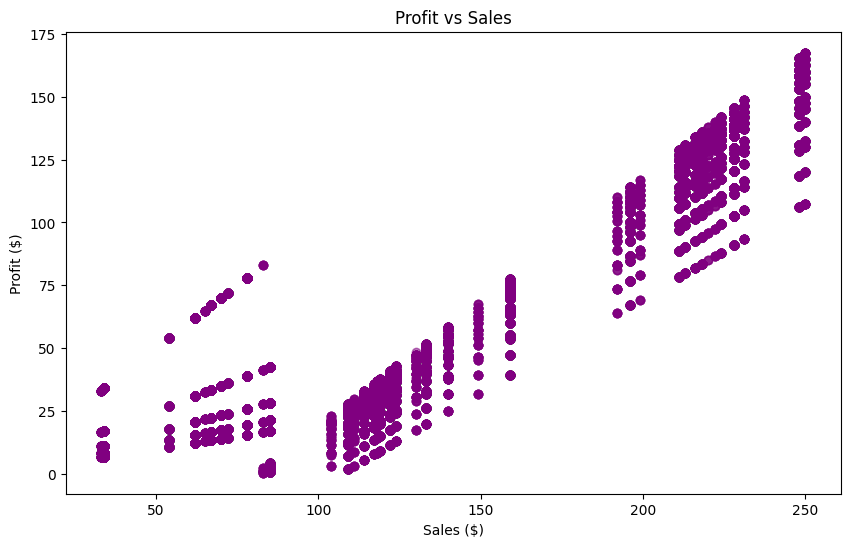

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(df["sales"], df["profit"], color="purple", alpha=0.3)
plt.title("Profit vs Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")
plt.show()

## Lucro vs Vendas
Há uma correlação positiva clara — quanto maior a venda, maior o lucro.
Os pontos formam grupos bem definidos, sugerindo faixas de preço fixas nos produtos.

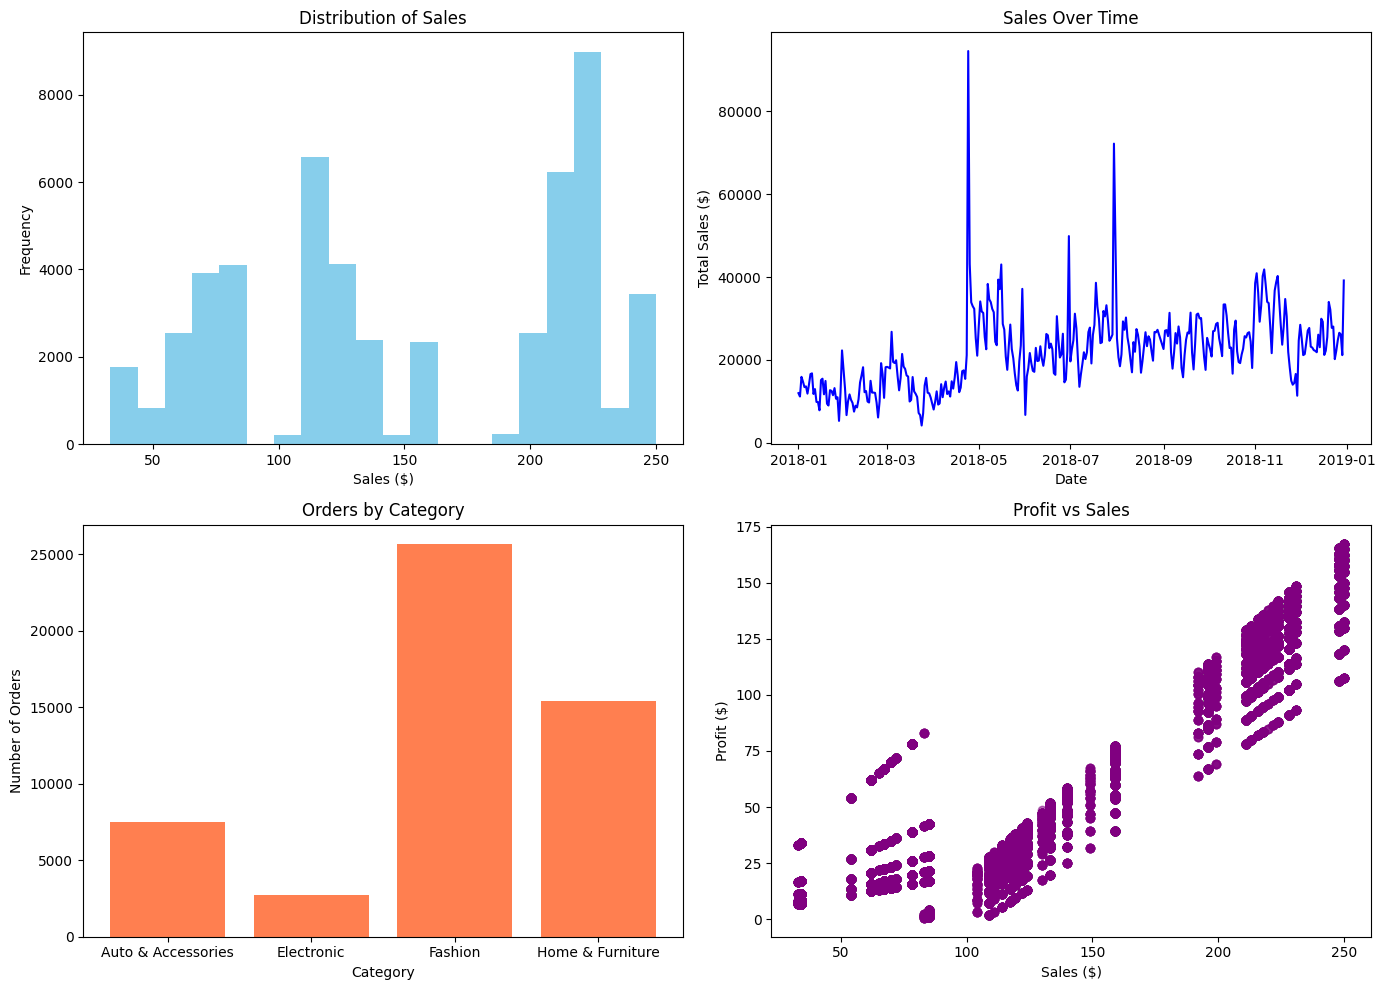

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Histograma
ax[0, 0].hist(df["sales"], bins=20, color="skyblue")
ax[0, 0].set_title("Distribution of Sales")
ax[0, 0].set_xlabel("Sales ($)")
ax[0, 0].set_ylabel("Frequency")

# Linha
ax[0, 1].plot(sales_over_time.index, sales_over_time.values, color="blue")
ax[0, 1].set_title("Sales Over Time")
ax[0, 1].set_xlabel("Date")
ax[0, 1].set_ylabel("Total Sales ($)")

# Barras
ax[1, 0].bar(category_orders.index, category_orders.values, color="coral")
ax[1, 0].set_title("Orders by Category")
ax[1, 0].set_xlabel("Category")
ax[1, 0].set_ylabel("Number of Orders")

# Dispersão
ax[1, 1].scatter(df["sales"], df["profit"], color="purple", alpha=0.3)
ax[1, 1].set_title("Profit vs Sales")
ax[1, 1].set_xlabel("Sales ($)")
ax[1, 1].set_ylabel("Profit ($)")

plt.tight_layout()
plt.show()